# 02_feature_engineering.ipynb

**Purpose:**
- Load train/val splits
- Compute per-sample descriptors (time-domain, spectral, spatial, geophysical)
- Inspect descriptor distributions
- Normalize and save feature matrix for downstream use


In [1]:
import os
import sys
from glob import glob

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from src.loaders import shuffle_and_split_data, get_training_ids
from src.features import (compute_time_stats, compute_envelope_stats, compute_spectral_stats, compute_spatial_stats)


plt.style.use('ggplot')
sns.set_context('notebook')

# Data paths
DATA_DIR = '../data/raw/train_data'
FEATURES_OUT = '../data/processed/features.csv'


In [2]:
_, all_ids = get_training_ids()
train_ids, val_ids = shuffle_and_split_data(all_ids, val_ratio=0.2)

print(f"→ {len(train_ids)} train samples, {len(val_ids)} val samples")

→ 1600 train samples, 400 val samples


In [3]:
records = []
for sid in train_ids + val_ids:
    path = os.path.join(DATA_DIR, sid)
    # load gathers: shape (5 shots, time, receivers)
    gathers = np.stack([
        np.load(os.path.join(path, f'receiver_data_src_{src}.npy'))
        for src in (1,75,150,225,300)
    ], axis=0)
    vp = np.load(os.path.join(path, 'vp_model.npy'))

    # time-domain
    m, s, r = compute_time_stats(gathers)
    # envelope
    e_mean, e_max = compute_envelope_stats(gathers)
    # spectral
    dfreq, scent = compute_spectral_stats(gathers)
    # spatial
    grad_m, curv_m = compute_spatial_stats(vp)
    # velocity range
    vp_range = vp.max() - vp.min()

    records.append({
        'sample_id': sid,
        'split':     'train' if sid in train_ids else 'val',
        'mean_amp':  m,
        'std_amp':   s,
        'rms_amp':   r,
        'env_mean':  e_mean,
        'env_max':   e_max,
        'dom_freq':  dfreq,
        'spec_cent': scent,
        'grad_mean': grad_m,
        'curv_mean': curv_m,
        'vp_range':  vp_range
    })

df_feats = pd.DataFrame(records)


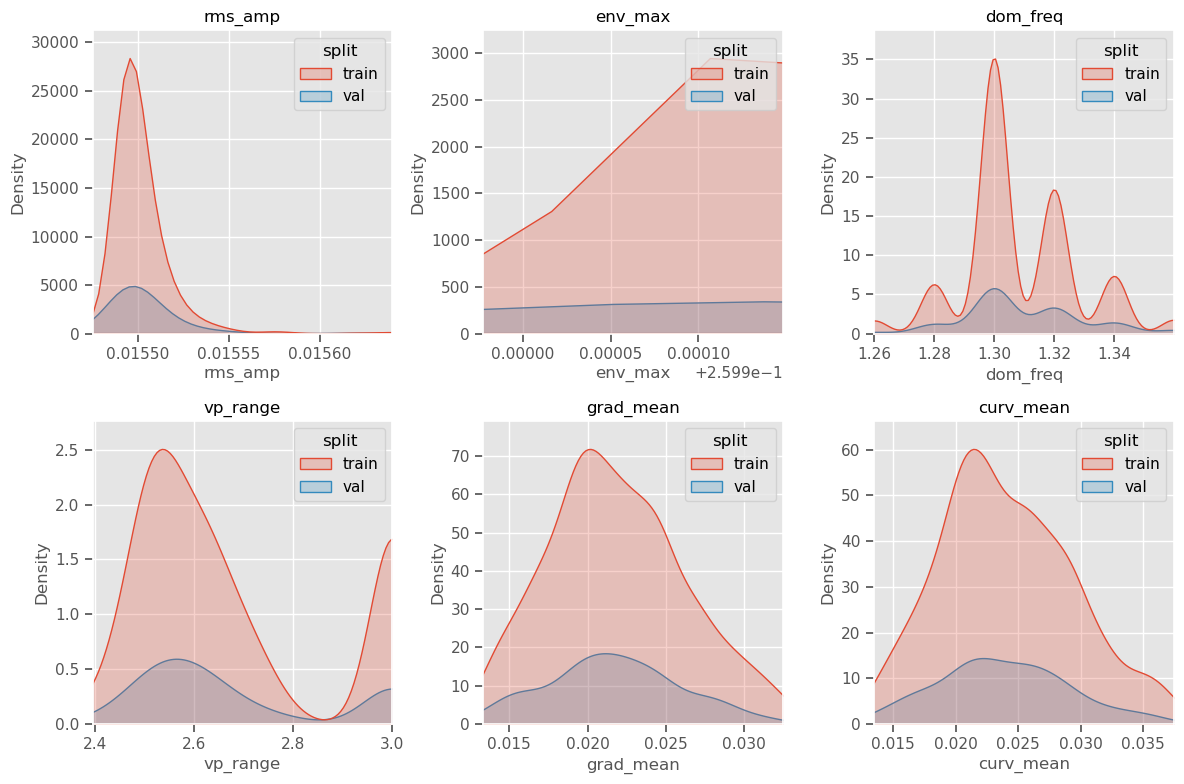

In [12]:
features = ['rms_amp','env_max','dom_freq','vp_range','grad_mean','curv_mean']
n_feats = len(features)
ncols = 3
nrows = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows),
                         sharex=False, sharey=False)
axes = axes.ravel()

for ax, feat in zip(axes, features):
    # Plot train & val KDE with fill
    sns.kdeplot(df_feats, x=feat, hue='split', fill=True, ax=ax)
    
    # Zoom X to central 1–99th percentile
    lo, hi = df_feats[feat].quantile([0.01, 0.99])
    ax.set_xlim(lo, hi)
    
    # Grab the auto‐computed y‐limits, then pad 5%
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.05)
    
    ax.set_title(feat)

# Turn off any extra axes
for ax in axes[n_feats:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


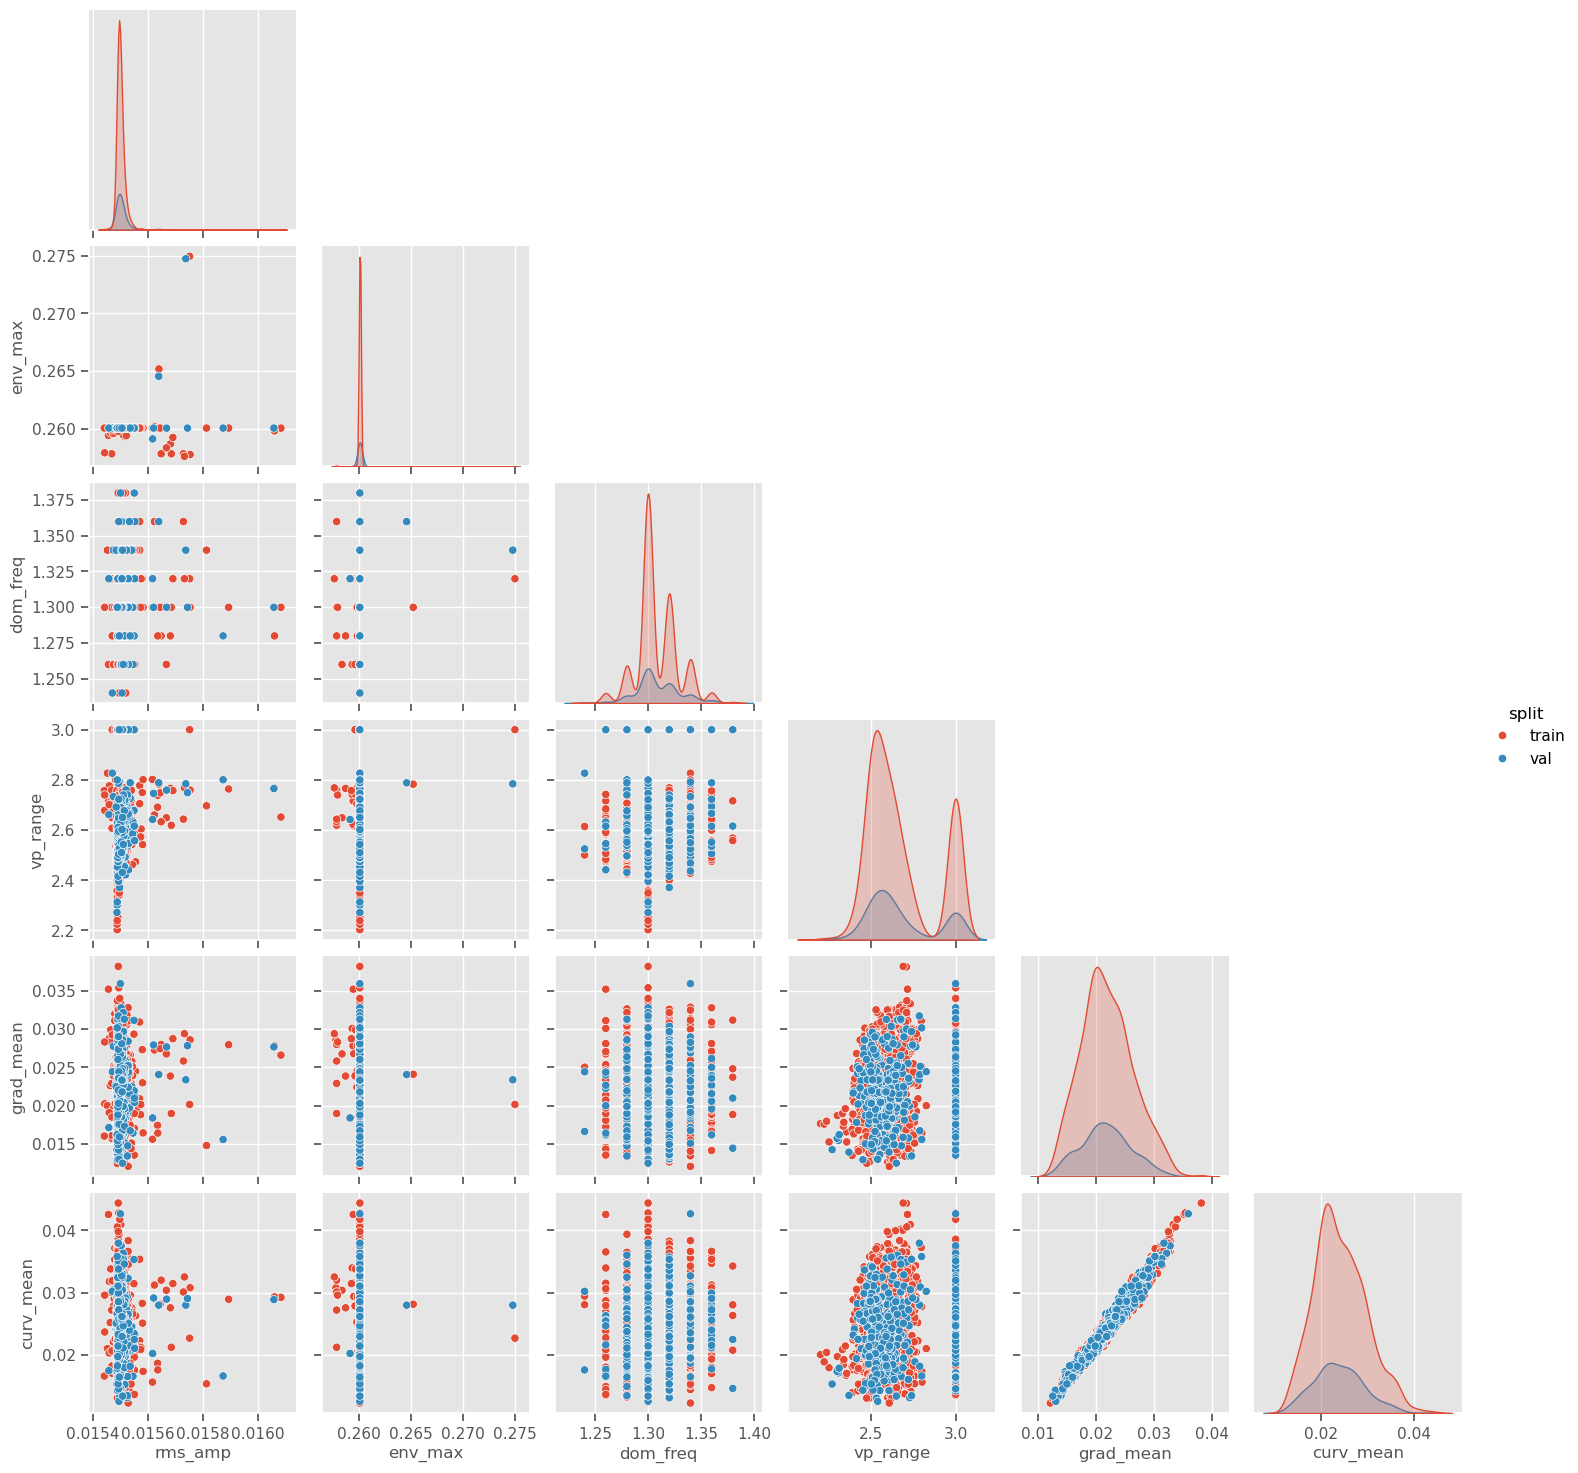

In [ ]:
# Pairplot on a subset of features
sns.pairplot(df_feats, vars=features, hue='split', corner=True)
plt.show()

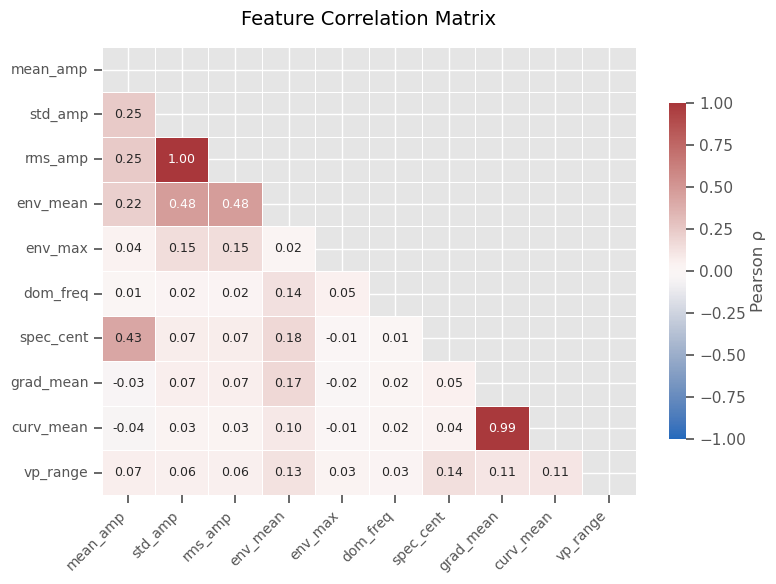

In [14]:
# Correlation matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Compute your correlation matrix (as you already did)
corr = df_feats.drop(columns=['sample_id','split']).corr()

# 2) Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3) Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    cmap='vlag',            # diverging palette
    vmin=-1, vmax=1,        # fixed color scale
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={"size": 9},  # font size of annotations
    linewidths=0.5,         # lines between cells
    linecolor='white',
    cbar_kws={"shrink": .75, "label": "Pearson ρ"}  # colorbar tweaks
)

# 4) Tidy up the axes
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title('Feature Correlation Matrix', pad=16, fontsize=14)
plt.tight_layout()
plt.show()


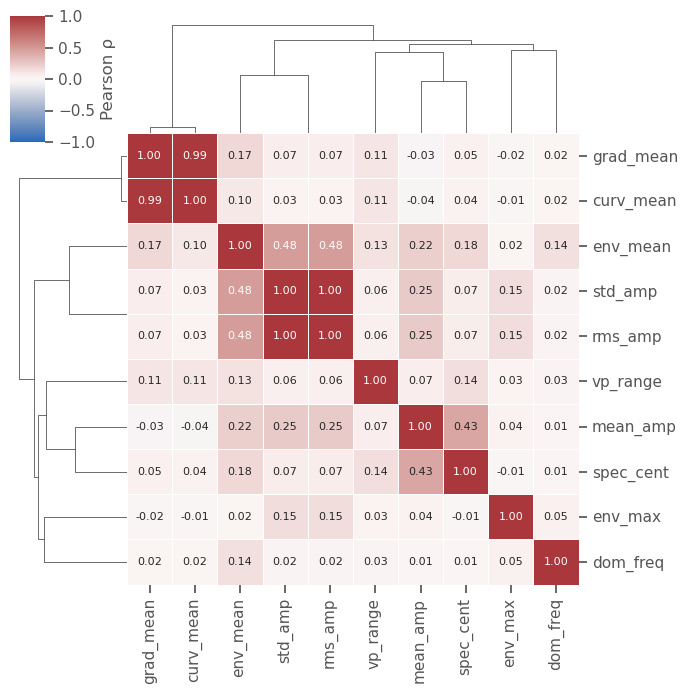

In [15]:
sns.clustermap(
    corr,
    cmap='vlag',
    vmin=-1, vmax=1,
    center=0,
    annot=True, fmt='.2f',
    linewidths=0.5,
    figsize=(7,7),
    cbar_kws={"shrink": .5, "label": "Pearson ρ"},
    row_cluster=True,
    col_cluster=True,
    annot_kws={"size": 8}
)
plt.show()


In [16]:
scaler = StandardScaler()
to_scale = ['mean_amp','std_amp','rms_amp','env_mean','env_max',
            'dom_freq','spec_cent','grad_mean','curv_mean','vp_range']
df_feats_scaled = df_feats.copy()
df_feats_scaled[to_scale] = scaler.fit_transform(df_feats[to_scale])

# Save full features plus split labels
df_feats_scaled.to_csv(FEATURES_OUT, index=False)
print(f"Saved features to {FEATURES_OUT}")

Saved features to ../data/processed/features.csv
